# Многослойный перцептрон

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

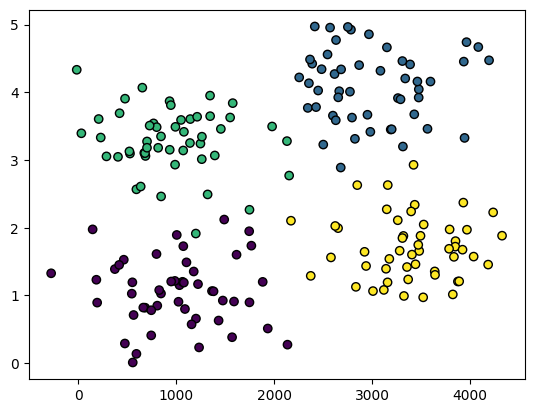

In [5]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, 
                          centers=blob_centers, 
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

In [6]:
clf = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1).fit(X, y)

In [7]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


In [8]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



In [9]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


In [10]:
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

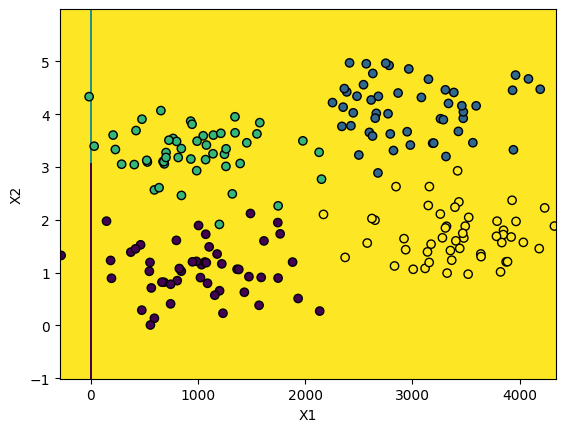

In [11]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

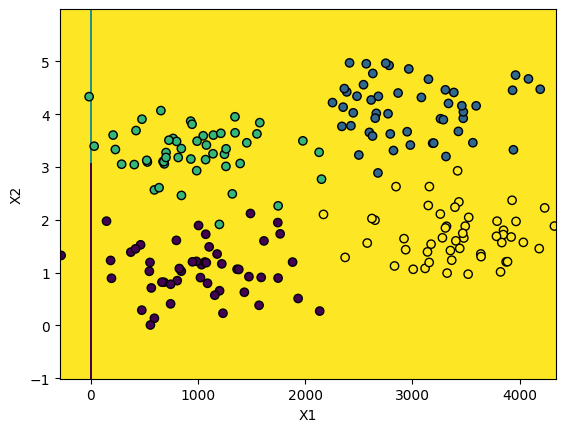

In [12]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = scaler.transform(X)

In [15]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10_000, verbose=True).fit(X_scaled, y)

Iteration 1, loss = 1.87640314
Iteration 2, loss = 1.87079319
Iteration 3, loss = 1.86520667
Iteration 4, loss = 1.85964532
Iteration 5, loss = 1.85410599
Iteration 6, loss = 1.84858991
Iteration 7, loss = 1.84309855
Iteration 8, loss = 1.83763204
Iteration 9, loss = 1.83219141
Iteration 10, loss = 1.82677776
Iteration 11, loss = 1.82138927
Iteration 12, loss = 1.81602596
Iteration 13, loss = 1.81068786
Iteration 14, loss = 1.80537488
Iteration 15, loss = 1.80008729
Iteration 16, loss = 1.79482669
Iteration 17, loss = 1.78959144
Iteration 18, loss = 1.78438160
Iteration 19, loss = 1.77919601
Iteration 20, loss = 1.77403187
Iteration 21, loss = 1.76889222
Iteration 22, loss = 1.76377915
Iteration 23, loss = 1.75869142
Iteration 24, loss = 1.75362903
Iteration 25, loss = 1.74859196
Iteration 26, loss = 1.74356587
Iteration 27, loss = 1.73856179
Iteration 28, loss = 1.73357165
Iteration 29, loss = 1.72860117
Iteration 30, loss = 1.72365692
Iteration 31, loss = 1.71873651
Iteration 32, los

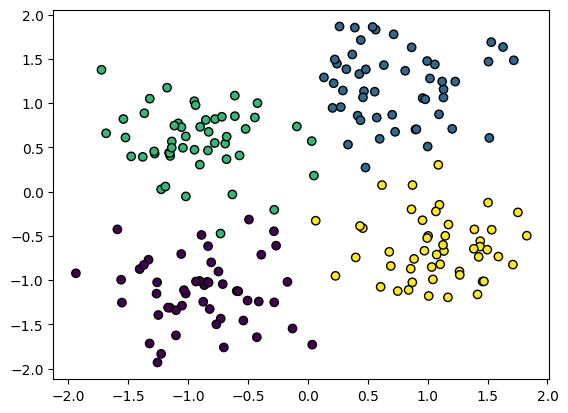

In [18]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.show()

In [19]:
y_pred = clf.predict(X_scaled)
print(confusion_matrix(y, y_pred))

[[49  0  1  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


[[49  0  1  0]
 [ 0 49  0  1]
 [ 1  0 49  0]
 [ 0  0  0 50]]


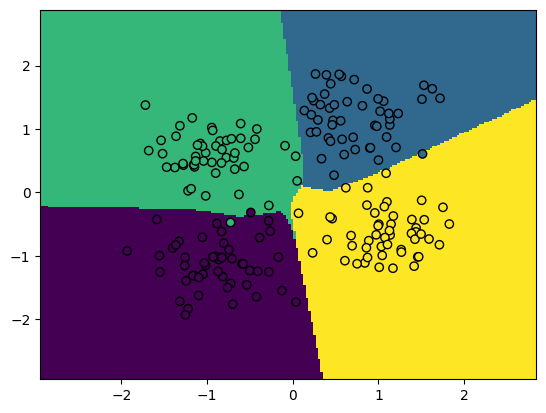

In [20]:
clf_deep = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10000, random_state=1).fit(X_scaled, y)
print(confusion_matrix(y, clf_deep.predict(X_scaled)))

# Визуализация границ для глубокой сети
X0 = np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)
y_predict = clf_deep.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.show()

# Задачи для самостоятельного решения

## Задание 1: Однослойный перцептрон — 1, 2, 10, 100 нейронов

In [ ]:
import time
import pandas as pd

rows = []
for n in [1, 2, 10, 100]:
    t0 = time.perf_counter()
    m = MLPClassifier(hidden_layer_sizes=(n,), max_iter=10000, random_state=1).fit(X_scaled, y)
    t = (time.perf_counter() - t0) * 1000
    rows.append({"neurons": n, "accuracy": m.score(X_scaled, y).round(4), "time_ms": round(t, 1)})

df1 = pd.DataFrame(rows).set_index("neurons")
print(df1)
# Вывод: уже 10 нейронов дают хорошую точность; 100 — незначительный прирост при большем времени.

## Задание 2: 2, 3, 10 скрытых слоёв с одинаковым числом нейронов

In [ ]:
rows2 = []
for n_layers in [1, 2, 3, 10]:
    arch = (6,) * n_layers  # 6 нейронов в каждом слое
    t0 = time.perf_counter()
    m = MLPClassifier(hidden_layer_sizes=arch, max_iter=10000, random_state=1).fit(X_scaled, y)
    t = (time.perf_counter() - t0) * 1000
    rows2.append({"layers": n_layers, "arch": str(arch),
                  "accuracy": m.score(X_scaled, y).round(4), "time_ms": round(t, 1)})

df2 = pd.DataFrame(rows2).set_index("layers")
print(df2)
# Вывод: для простой задачи 2–3 слоя достаточно; 10 слоёв могут ухудшить результат (vanishing gradient).

## Задание 3: Веса и смещения глубокой модели (3 слоя)

In [ ]:
deep = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10000, random_state=1).fit(X_scaled, y)

for layer_idx, (W, b) in enumerate(zip(deep.coefs_, deep.intercepts_)):
    print(f"--- Слой {layer_idx}: форма весов {W.shape} ---")
    print("Матрица весов:\n", W.round(3))
    print("Вектор смещений:", b.round(3))
    print()

## Задание 4: Большая модель — замер времени vs простые модели

In [ ]:
configs = {
    "small  (6,)":          (6,),
    "medium (6,6,6)":       (6, 6, 6),
    "large  (128,128,128)": (128, 128, 128),
    "huge   (256,)*5":      (256,) * 5,
}

rows4 = []
for name, arch in configs.items():
    t0 = time.perf_counter()
    m = MLPClassifier(hidden_layer_sizes=arch, max_iter=10000, random_state=1).fit(X_scaled, y)
    t = (time.perf_counter() - t0) * 1000
    rows4.append({"модель": name, "accuracy": m.score(X_scaled, y).round(4), "time_ms": round(t, 1)})

df4 = pd.DataFrame(rows4).set_index("модель")
print(df4)
# Вывод: большие архитектуры не всегда дают прирост точности, но заметно дольше обучаются.

## Задание 5: Классификация — датасет Breast Cancer

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report
import seaborn as sns

bc = load_breast_cancer()
X_bc = StandardScaler().fit_transform(bc.data)
y_bc = bc.target

# Подбираем несколько архитектур
for arch in [(32,), (64, 32), (128, 64, 32)]:
    m = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=0).fit(X_bc, y_bc)
    print(f"arch={arch}  accuracy={m.score(X_bc,y_bc):.4f}")

# Лучшая модель — подробный отчёт
best = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=0).fit(X_bc, y_bc)
print("\n", classification_report(y_bc, best.predict(X_bc), target_names=bc.target_names))

sns.heatmap(confusion_matrix(y_bc, best.predict(X_bc)), annot=True, fmt='d',
            xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.title("MLP — Breast Cancer")
plt.show()

## Задание 6: Регрессия — MLPRegressor на датасете California Housing

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score, mean_absolute_error

ca = fetch_california_housing()
X_ca = StandardScaler().fit_transform(ca.data)
y_ca = ca.target

rows6 = []
for arch in [(32,), (64, 32), (128, 64, 32)]:
    t0 = time.perf_counter()
    m = MLPRegressor(hidden_layer_sizes=arch, max_iter=500, random_state=0).fit(X_ca, y_ca)
    t = (time.perf_counter() - t0) * 1000
    yp = m.predict(X_ca)
    rows6.append({"arch": str(arch),
                  "R²":   round(r2_score(y_ca, yp), 4),
                  "MAE":  round(mean_absolute_error(y_ca, yp), 4),
                  "time_ms": round(t, 1)})

df6 = pd.DataFrame(rows6).set_index("arch")
print(df6)

# График: предсказание vs факт для лучшей модели
best_r = MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=0).fit(X_ca, y_ca)
yp = best_r.predict(X_ca)
plt.figure(figsize=(5, 4))
plt.scatter(yp, y_ca, s=2, alpha=0.3)
plt.plot([y_ca.min(), y_ca.max()], [y_ca.min(), y_ca.max()], 'r')
plt.title(f"MLPRegressor (128,64,32)  R²={r2_score(y_ca,yp):.3f}")
plt.xlabel("ŷ"); plt.ylabel("y")
plt.show()